# Power Spectrum & Halo Mass Function Models

Validates `beorn.lpt.EisensteinHu` and `beorn.lpt.DiscoEB` against CAMB and demonstrates
JAX differentiability.  Validates `beorn.mass_function.HaloMassFunction` against
colossus.

**Sections**
1. [Imports & setup](#1-Imports-&-setup)
2. [Linear Power Spectrum — E&H](#2-Linear-Power-Spectrum)
3. [σ₈ normalisation check](#3-σ₈-normalisation-check)
4. [Validation against CAMB & DISCO-EB](#4-Validation-against-CAMB)
5. [Differentiability of P(k)](#5-Differentiability-of-P(k))
6. [Default HMF model: Sheth-Tormen](#6-Default-HMF-model)
7. [Comparing HMF models](#7-Comparing-HMF-models)
8. [Window functions](#8-Window-functions)
9. [Named runners](#9-Named-runners)
10. [Validation against colossus](#10-Validation-against-colossus)
11. [JAX backend & HMF gradients](#11-JAX-backend)
12. [PyTorch backend & autograd](#12-PyTorch-backend)

## 1  Imports & setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import quad

from beorn.structs import Parameters
from beorn.lpt import EisensteinHu, DiscoEB, get_power_spectrum
from beorn.cosmo import D
from beorn.mass_function import (
    HaloMassFunction, PressSchechter, ShethTormen,
)

param = Parameters()
cosmo = param.cosmology
M     = np.logspace(8, 15, 100)
dlnM  = np.diff(np.log(M)).mean()   # uniform log-spacing ~= ln(10)*7/99
z     = 7.0
print(f'Ωm={cosmo.Om}  Ωb={cosmo.Ob}  h={cosmo.h0}  σ₈={cosmo.sigma_8}  ns={cosmo.ns}')

Ωm=0.315  Ωb=0.045  h=0.673  σ₈=0.83  ns=0.96


## 2  Linear Power Spectrum

`EisensteinHu` implements the Eisenstein & Hu (1998) transfer function in two variants:

| Variant | Description | Use case |
|---|---|---|
| `wiggle=False` (default) | Smooth no-wiggle shape | Fast HMF and σ² integrals |
| `wiggle=True` | Full fit including BAO features | BAO-sensitive statistics |

Both variants are calibrated to the `sigma_8` in `Parameters.cosmology` via
a self-consistent amplitude $A_s$.  The factory `get_power_spectrum('eisenstein_hu', param)`
returns the no-wiggle variant.

sigma_8 target  = 0.83
A_s (no-wiggle) = 2.85365e+06
A_s (wiggle)    = 3.04762e+06


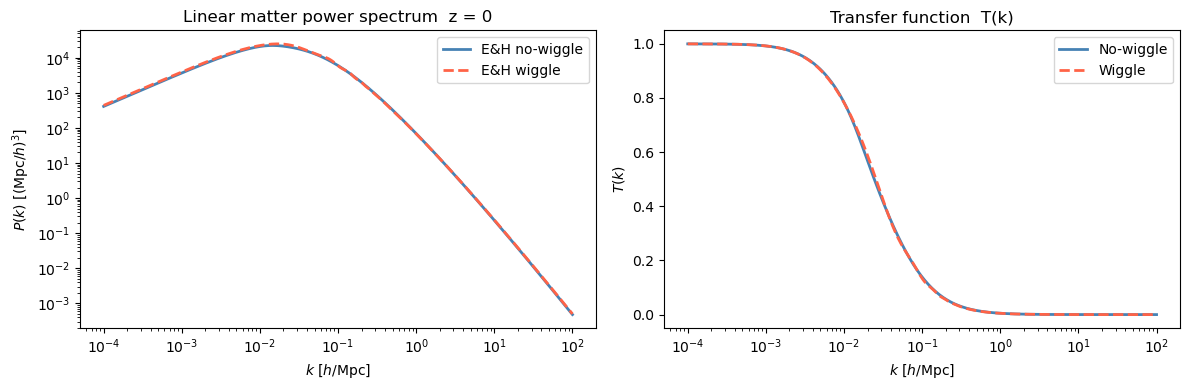

In [2]:
k = np.logspace(-4, 2, 500)

ps_nw  = EisensteinHu(param, wiggle=False)   # smooth no-wiggle (default)
ps_wig = EisensteinHu(param, wiggle=True)    # full BAO wiggles

print(f"sigma_8 target  = {param.cosmology.sigma_8}")
print(f"A_s (no-wiggle) = {ps_nw.A_s:.5e}")
print(f"A_s (wiggle)    = {ps_wig.A_s:.5e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.loglog(k, ps_nw.P(k, z=0),  lw=2.0, color='steelblue', label='E&H no-wiggle')
ax.loglog(k, ps_wig.P(k, z=0), lw=2.0, color='tomato', ls='--', label='E&H wiggle')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$P(k)\ [(\mathrm{Mpc}/h)^3]$')
ax.set_title('Linear matter power spectrum  z = 0')
ax.legend()

ax = axes[1]
ax.semilogx(k, ps_nw.transfer(k),  lw=2.0, color='steelblue', label='No-wiggle')
ax.semilogx(k, ps_wig.transfer(k), lw=2.0, color='tomato', ls='--', label='Wiggle')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$T(k)$')
ax.set_title('Transfer function  T(k)')
ax.legend()

plt.tight_layout()
plt.show()

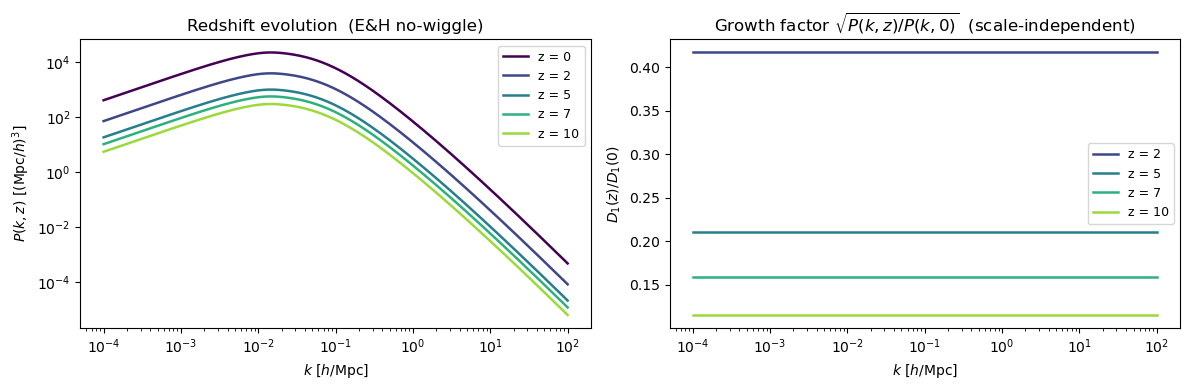

In [3]:
redshifts = [0.0, 2.0, 5.0, 7.0, 10.0]
colors    = plt.cm.viridis(np.linspace(0.0, 0.85, len(redshifts)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for z_i, c in zip(redshifts, colors):
    ax.loglog(k, ps_nw.P(k, z=z_i), lw=1.8, color=c, label=f'z = {z_i:.0f}')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$P(k, z)\ [(\mathrm{Mpc}/h)^3]$')
ax.set_title('Redshift evolution  (E&H no-wiggle)')
ax.legend(fontsize=9)

P0 = ps_nw.P(k, z=0.0)
ax = axes[1]
for z_i, c in zip(redshifts[1:], colors[1:]):
    growth = np.sqrt(ps_nw.P(k, z=z_i) / P0)
    ax.semilogx(k, growth, lw=1.8, color=c, label=f'z = {z_i:.0f}')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$D_1(z) / D_1(0)$')
ax.set_title(r'Growth factor $\sqrt{P(k,z)/P(k,0)}$  (scale-independent)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 3  σ₈ normalisation check

Integrate $P(k)$ against the real-space top-hat window of radius $8\,h^{-1}\mathrm{Mpc}$
and verify that both E&H variants recover the input $\sigma_8$.  Also plots the
linear growth factor $D(z)/D(0)$.

σ₈ (no-wiggle) = 0.83001   target = 0.83
σ₈ (wiggle) = 0.83001   target = 0.83


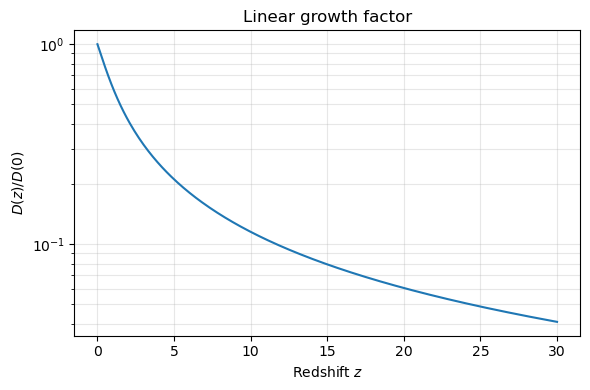

In [4]:
def sigma_r(ps, R, z=0):
    """rms density fluctuation in spheres of radius R (Mpc/h)."""
    def integrand(lnk):
        k_ = np.exp(lnk)
        x  = k_ * R
        W  = 3 * (np.sin(x) - x * np.cos(x)) / x**3
        return k_**3 * ps.P(k_, z=z) * W**2 / (2 * np.pi**2)
    result, _ = quad(integrand, np.log(1e-4), np.log(1e3), limit=300)
    return np.sqrt(result)

k = np.logspace(-4, 2, 500)
ps_nw  = EisensteinHu(param, wiggle=False)
ps_wig = EisensteinHu(param, wiggle=True)

for label, ps in [('no-wiggle', ps_nw), ('wiggle', ps_wig)]:
    s8 = sigma_r(ps, R=8, z=0)
    print(f'σ₈ ({label}) = {s8:.5f}   target = {cosmo.sigma_8}')

# Growth factor vs redshift
zz = np.linspace(0, 30, 300)
aa = 1 / (1 + zz)
Dz = np.array([D(a, param) / D(1.0, param) for a in aa])

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(zz, Dz)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$D(z)/D(0)$')
ax.set_title('Linear growth factor')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 4  Validation against CAMB & DISCO-EB

We compare the E&H approximations and the DISCO-EB Boltzmann solver against
CAMB's full Boltzmann solution, all normalised to the same $\sigma_8 = 0.83$.

**CAMB** is the reference (full numerical Boltzmann solver).
**DISCO-EB** (`beorn.lpt.DiscoEB`) solves the linearised Boltzmann hierarchy in
JAX and is differentiable w.r.t. all cosmological parameters.

> **Note:** `DiscoEB` JIT-compiles on the first call (~1 min on CPU, ~3 s on GPU).
> If `disco-eb` is not installed the cell below skips it gracefully.

Note: redshifts have been re-sorted (earliest first)


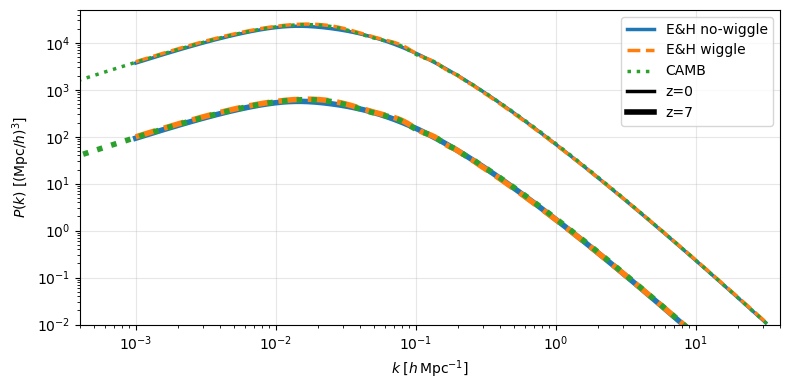

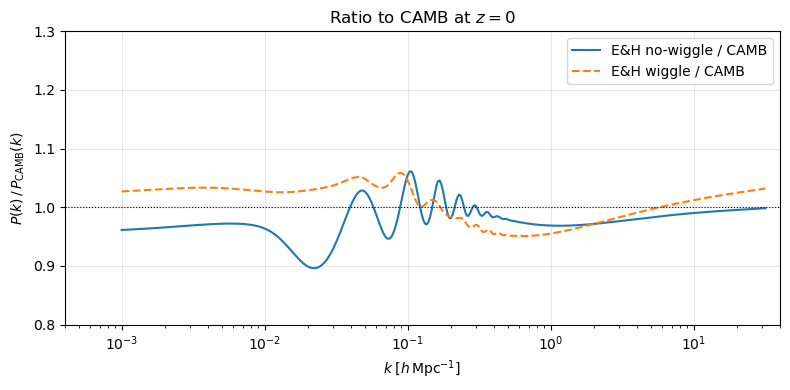

D(z=7)/D(0): BEoRN=0.1586  CAMB=0.1593  diff=0.45%


In [5]:
import camb

h0, Om, Ob, ns_cosm, sig8 = cosmo.h0, cosmo.Om, cosmo.Ob, cosmo.ns, cosmo.sigma_8

pars = camb.CAMBparams()
pars.set_cosmology(H0=100*h0, ombh2=Ob*h0**2, omch2=(Om-Ob)*h0**2, TCMB=2.7255)
pars.InitPower.set_params(ns=ns_cosm, As=2.1e-9)
pars.set_matter_power(redshifts=[0.0, 7.0], kmax=200.0)
results = camb.get_results(pars)

sig8_camb  = results.get_sigma8_0()
rescale_sq = (sig8 / sig8_camb) ** 2

kh_c, z_c, Pk_c = results.get_matter_power_spectrum(minkh=1e-4, maxkh=100.0, npoints=500)
Pk_camb_z0 = Pk_c[0] * rescale_sq
Pk_camb_z7 = Pk_c[1] * rescale_sq

# # ── DISCO-EB (optional) ───────────────────────────────────────────────────────
# _DISCOEB_AVAILABLE = False
# try:
#     print('Initialising DiscoEB (JIT compilation may take ~1 min on first run)...')
#     ps_deb = DiscoEB(param, num_k=256)  # kmax_hmpc=1.0 h/Mpc by default
#     _DISCOEB_AVAILABLE = True
#     print('DiscoEB ready.')
# except ImportError:
#     print('disco-eb not installed — skipping DISCO-EB comparison.')
#     print('Install: pip install git+https://github.com/ohahn/DISCO-EB.git')

# ── P(k) comparison plots ─────────────────────────────────────────────────────
k_plt = np.logspace(-3, 1.5, 400)
fig, ax = plt.subplots(figsize=(8, 4))

for z_plt, Pk_cam, lw in zip([0.0, 7.0], [Pk_camb_z0, Pk_camb_z7], [2.5,4.0]):
    ax.loglog(k_plt, ps_nw.P(k_plt, z=z_plt),  lw=lw, ls='-',   c='C0', label='E&H no-wiggle' if z_plt == 0.0 else None)
    ax.loglog(k_plt, ps_wig.P(k_plt, z=z_plt), lw=lw, ls='--',  c='C1', label='E&H wiggle'  if z_plt == 0.0 else None)
    ax.loglog(kh_c,  Pk_cam,                   lw=lw, ls=':',   c='C2',  label='CAMB' if z_plt == 0.0 else None)
    # if _DISCOEB_AVAILABLE:
    #     k_deb = k_plt[k_plt <= ps_deb._kmax_hmpc]
    #     ax.loglog(k_deb, ps_deb.P(k_deb, z=z_plt), lw=1.5, ls='-.', label='DISCO-EB')
    ax.plot([], [], lw=lw, ls='-', color='k', label=f'z={z_plt:.0f}')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
# ax.set_title(f'$z = {z_plt}$')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(1e-2, 5e4)
ax.set_xlim(4e-4, 40)

plt.tight_layout()
plt.show()

# ── Ratio to CAMB ─────────────────────────────────────────────────────────────
from scipy.interpolate import interp1d as _interp1d
log_cam = _interp1d(np.log(kh_c), np.log(Pk_camb_z0), kind='linear',
                    bounds_error=False, fill_value='extrapolate')
Pk_cam_ref = np.exp(log_cam(np.log(k_plt)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(k_plt, ps_nw.P(k_plt,  z=0) / Pk_cam_ref, label='E&H no-wiggle / CAMB')
ax.semilogx(k_plt, ps_wig.P(k_plt, z=0) / Pk_cam_ref, label='E&H wiggle / CAMB', ls='--')
# if _DISCOEB_AVAILABLE:
#     k_deb = k_plt[k_plt <= ps_deb._kmax_hmpc]
#     Pk_cam_deb = np.exp(log_cam(np.log(k_deb)))
#     ax.semilogx(k_deb, ps_deb.P(k_deb, z=0) / Pk_cam_deb, label='DISCO-EB / CAMB', ls='-.')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\,/\,P_\mathrm{CAMB}(k)$')
ax.set_title('Ratio to CAMB at $z=0$')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 1.3)
ax.set_xlim(4e-4, 40)
plt.tight_layout()
plt.show()

# ── Growth factor comparison ──────────────────────────────────────────────────
idx7 = np.argmin(np.abs(kh_c - 0.1))
D_ratio_beorn = ps_nw._growth_ratio(7.0)
D_ratio_camb  = np.sqrt(Pk_c[1][idx7] / Pk_c[0][idx7])
print(f'D(z=7)/D(0): BEoRN={D_ratio_beorn:.4f}  CAMB={D_ratio_camb:.4f}  '
      f'diff={abs(D_ratio_beorn-D_ratio_camb)/D_ratio_camb*100:.2f}%')

## 5  Differentiability of P(k)

The linear power spectrum factors as

$$P(k, z) = A_s \cdot k^{n_s} \cdot T^2(k) \cdot D_1^2(z)$$

Treating $T^2(k)$ as a frozen pre-computed constant (E&H fit), JAX can
differentiate through the remaining scalar parameters:

| Parameter | $\partial \ln P / \partial \theta$ | Physical meaning |
|---|---|---|
| $A_s$ | $1$ | amplitude scale |
| $n_s$ | $\ln k$ | spectral tilt |

Both are verified against their analytic values to machine precision below.

> **Note:** Full cosmological-parameter gradients ($\partial P/\partial \Omega_m$,
> $\partial P/\partial \Omega_b$) require a JAX-native transfer function — tracked in
> issue #39.

In [6]:
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

# T²(k) and D(z)² are frozen numpy constants; differentiate only
# through A_s and n_s which enter the spectrum analytically.
T_sq_np  = ps_nw.transfer(k) ** 2
D_sq_0   = float(ps_nw._growth_ratio(0.0) ** 2)
k_jax    = jnp.asarray(k)
T_sq_jax = jnp.asarray(T_sq_np)
A_s_ref  = float(ps_nw.A_s)
ns_ref   = float(param.cosmology.ns)

def Pk_jax(A_s, ns_scalar):
    """P(k, z=0): differentiable w.r.t. A_s and n_s (T² is a constant)."""
    return A_s * k_jax ** ns_scalar * T_sq_jax * D_sq_0

# ∂(Σ P)/∂A_s  should equal  Σ P / A_s
grad_As  = jax.grad(lambda As: Pk_jax(As, ns_ref).sum())(A_s_ref)
check_As = float(np.sum(ps_nw.P(k, z=0)) / A_s_ref)
print(f'∂(ΣP)/∂A_s   JAX = {float(grad_As):.6e}   analytic = {check_As:.6e}   '
      f'rel err = {abs(float(grad_As) - check_As) / check_As:.2e}')

# ∂P_i/∂n_s  should equal  P_i · ln k_i
dPk_dns  = jax.jacobian(lambda ns: Pk_jax(A_s_ref, ns))(ns_ref)
check_ns = ps_nw.P(k, z=0) * np.log(k)
valid_k  = np.abs(np.log(k)) > 0.1   # exclude k ≈ 1 where analytic → 0
max_err  = float(np.max(np.abs(np.asarray(dPk_dns)[valid_k] - check_ns[valid_k])
                        / np.abs(check_ns[valid_k])))
print(f'∂P_i/∂n_s   max rel err vs P·ln k = {max_err:.2e}')

∂(ΣP)/∂A_s   JAX = 8.941094e-01   analytic = 8.941094e-01   rel err = 3.73e-16
∂P_i/∂n_s   max rel err vs P·ln k = 3.76e-16


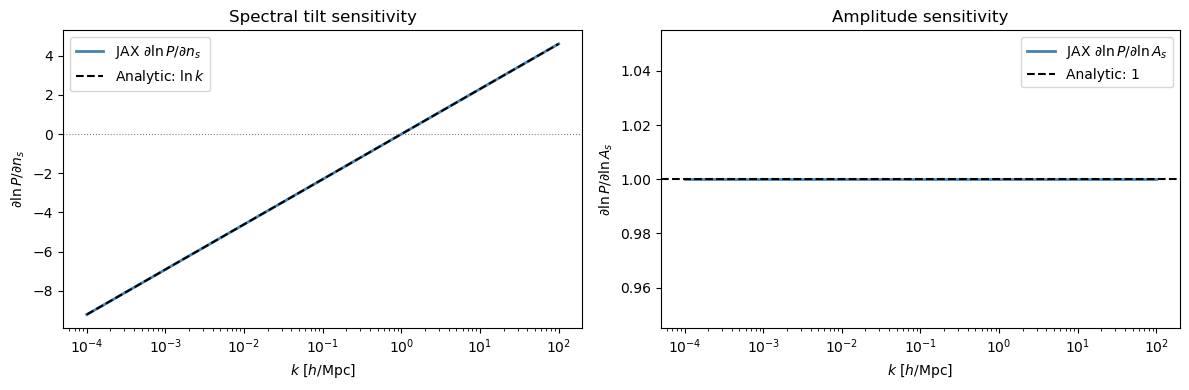

∂ln P/∂n_s      max|JAX − ln k| / |ln k| = 3.47e-16
∂ln P/∂ln A_s   max|JAX − 1|              = 2.22e-16


In [7]:
# ∂ ln P / ∂ n_s = ln k — spectral tilt derivative
dlogP_dns_jax      = np.asarray(dPk_dns) / ps_nw.P(k, z=0)
dlogP_dns_analytic = np.log(k)

# ∂ ln P / ∂ ln A_s = 1 for all k (amplitude scaling)
dlogP_dlnAs = jax.jacobian(
    lambda lnAs: jnp.log(Pk_jax(jnp.exp(lnAs), ns_ref))
)(float(np.log(A_s_ref)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogx(k, dlogP_dns_jax,      lw=2.0, color='steelblue',
            label=r'JAX $\partial \ln P / \partial n_s$')
ax.semilogx(k, dlogP_dns_analytic, lw=1.5, ls='--', color='k',
            label=r'Analytic: $\ln k$')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$\partial \ln P / \partial n_s$')
ax.set_title('Spectral tilt sensitivity')
ax.legend()

ax = axes[1]
ax.semilogx(k, np.asarray(dlogP_dlnAs), lw=2.0, color='steelblue',
            label=r'JAX $\partial \ln P / \partial \ln A_s$')
ax.axhline(1.0, color='k', lw=1.5, ls='--', label='Analytic: 1')
ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$\partial \ln P / \partial \ln A_s$')
ax.set_title('Amplitude sensitivity')
ax.legend()

plt.tight_layout()
plt.show()

k_valid = (k > 1e-3) & (k < 50) & (np.abs(np.log(k)) > 0.1)
print(f'∂ln P/∂n_s      max|JAX − ln k| / |ln k| = '
      f'{np.max(np.abs(dlogP_dns_jax[k_valid] - dlogP_dns_analytic[k_valid]) / np.abs(dlogP_dns_analytic[k_valid])):.2e}')
print(f'∂ln P/∂ln A_s   max|JAX − 1|              = '
      f'{np.max(np.abs(np.asarray(dlogP_dlnAs) - 1.0)):.2e}')

## 6  Default HMF model: Sheth-Tormen

The unified entry point is `HaloMassFunction`.  Without arguments it uses
Sheth-Tormen (p=0.3, q=0.707), a top-hat window, and the numpy backend.

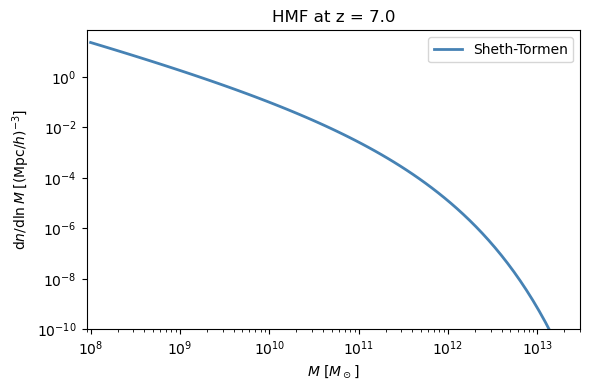

In [8]:
hmf = HaloMassFunction(param)           # ST, tophat, numpy
n   = hmf.dndlnm(M, z=z)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(M, n, lw=2, color='steelblue', label='Sheth-Tormen')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\mathrm{d}n / \mathrm{d}\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
ax.set_title(f'HMF at z = {z}')
ax.set_ylim(1e-10, 70)
ax.set_xlim(9e7, 3e13)
ax.legend()
plt.tight_layout()
plt.show()

## 7  Comparing HMF models

All three parametric models share the functional form

$$f(\nu) = A\sqrt{\frac{2q\nu}{\pi}}\left(1 + (q\nu)^{-p}\right)e^{-q\nu/2}$$

| Model | $p$ | $q$ | $A$ |
|---|---|---|---|
| Press-Schechter | 0 | 1 | 0.5 |
| Sheth-Tormen | 0.3 | 0.707 | ≈0.3222 |
| Ellipsoidal | 0.3 | 1 | ≈0.3222 |

`HaloMassFunction` pre-computes $\sigma^2(M)$ once; calling `run_*` runners
or `dndlnm(..., p=..., q=...)` reuses the same interpolated grid.

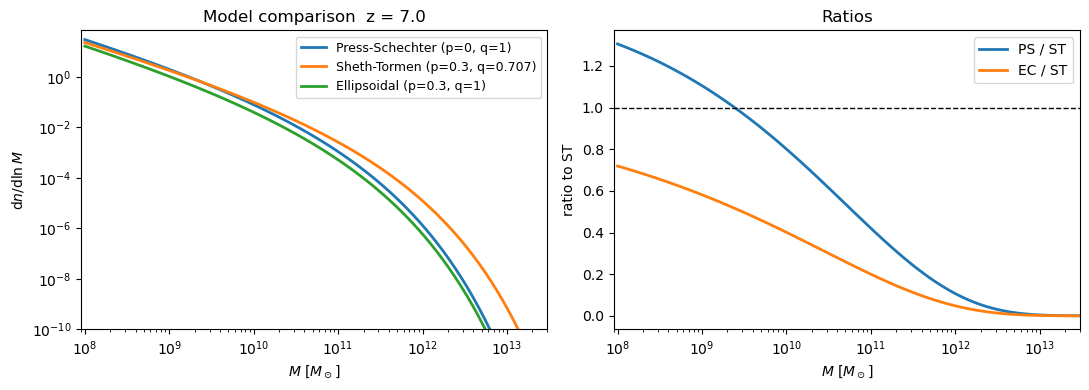

In [9]:
n_ps = hmf.run_press_schechter(M, z)
n_st = hmf.run_sheth_tormen(M, z)
n_ec = hmf.run_ellipsoidal(M, z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.loglog(M, n_ps, lw=2, label='Press-Schechter (p=0, q=1)')
ax.loglog(M, n_st, lw=2, label='Sheth-Tormen (p=0.3, q=0.707)')
ax.loglog(M, n_ec, lw=2, label='Ellipsoidal (p=0.3, q=1)')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M$')
ax.set_title(f'Model comparison  z = {z}')
ax.set_ylim(1e-10, 70)
ax.set_xlim(9e7, 3e13)
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogx(M, n_ps / n_st, lw=2, label='PS / ST')
ax.semilogx(M, n_ec / n_st, lw=2, label='EC / ST')
ax.axhline(1, color='k', lw=1, ls='--')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel('ratio to ST')
ax.set_title('Ratios')
ax.set_xlim(9e7, 3e13)
ax.legend()

plt.tight_layout()
plt.show()

## 8  Window functions

The window function $W(kR)$ controls the $\sigma^2(M)$ smoothing integral:

$$\sigma^2(M) = \int \frac{\mathrm{d}k}{k}\,\frac{k^3 P(k)}{2\pi^2}\,W^2(kR)$$

| Name | $W(x)$ |
|---|---|
| `'tophat'` | $3j_1(x)/x$ (real-space top-hat) |
| `'sharp_k'` | $\Theta(1-x)$ (Fourier step) |
| `'smooth_k'` | $(1+x^\beta)^{-1}$ ($\beta=4$ default) |

The M–R relation $M = \frac{4\pi}{3}\rho_m R^3$ is the same for all windows.

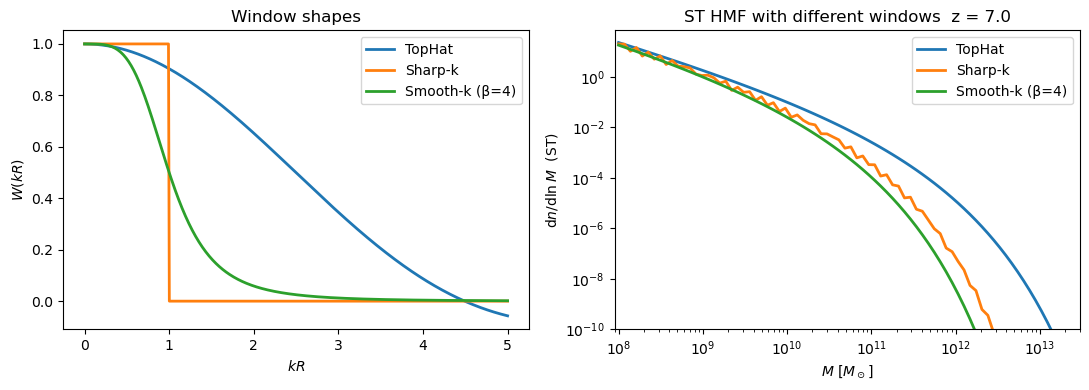

In [10]:
hmf_th  = HaloMassFunction(param, window='tophat')
hmf_sk  = HaloMassFunction(param, window='sharp_k')
hmf_smk = HaloMassFunction(param, window='smooth_k')   # beta=4

n_th  = hmf_th.dndlnm(M, z)
n_sk  = hmf_sk.dndlnm(M, z)
n_smk = hmf_smk.dndlnm(M, z)

# -- window shapes --
from beorn.mass_function import TopHatWindow, SharpKWindow, SmoothKWindow
x = np.linspace(0, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(x, TopHatWindow().W(x),  lw=2, label='TopHat')
ax.plot(x, SharpKWindow().W(x),  lw=2, label='Sharp-k')
ax.plot(x, SmoothKWindow().W(x), lw=2, label='Smooth-k (β=4)')
ax.set_xlabel(r'$kR$')
ax.set_ylabel(r'$W(kR)$')
ax.set_title('Window shapes')
ax.legend()

ax = axes[1]
ax.loglog(M, n_th,  lw=2, label='TopHat')
ax.loglog(M, n_sk,  lw=2, label='Sharp-k')
ax.loglog(M, n_smk, lw=2, label='Smooth-k (β=4)')
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M$  (ST)')
ax.set_title(f'ST HMF with different windows  z = {z}')
ax.set_ylim(1e-10, 70)
ax.set_xlim(9e7, 3e13)
ax.legend()

plt.tight_layout()
plt.show()

## 9  Named runners

`run_*` methods share the pre-computed $\sigma^2(M)$ grid — only the
$(p, q, A)$ tuple changes.  This is the cheapest way to compare models.

In [11]:
hmf_base = HaloMassFunction(param)   # single sigma^2 precomputation

for z_run in [6.0, 8.0, 10.0]:
    n_ps_z = hmf_base.run_press_schechter(M, z_run)
    n_st_z = hmf_base.run_sheth_tormen(M, z_run)
    print(f'z={z_run:.0f}  n(>1e10 Msun) PS={np.sum(n_ps_z[M>=1e10])*dlnM:.3e}  '
          f'ST={np.sum(n_st_z[M>=1e10])*dlnM:.3e}  (Mpc/h)^-3')

# Custom (p, q) via dndlnm overrides
n_custom = hmf_base.dndlnm(M, z, p=0.2, q=0.8)
print(f'Custom (p=0.2, q=0.8)  n(>1e10)={np.sum(n_custom[M>=1e10])*dlnM:.3e}')

z=6  n(>1e10 Msun) PS=1.009e-01  ST=1.146e-01  (Mpc/h)^-3
z=8  n(>1e10 Msun) PS=1.694e-02  ST=3.209e-02  (Mpc/h)^-3
z=10  n(>1e10 Msun) PS=1.737e-03  ST=6.308e-03  (Mpc/h)^-3
Custom (p=0.2, q=0.8)  n(>1e10)=4.870e-02


## 10  Validation against colossus

`colossus` (Diemer 2018) is an independent HMF library implementing PS, ST, and
calibrated models.  We compare BEoRN against colossus at the same cosmology.

Install: `pip install colossus`

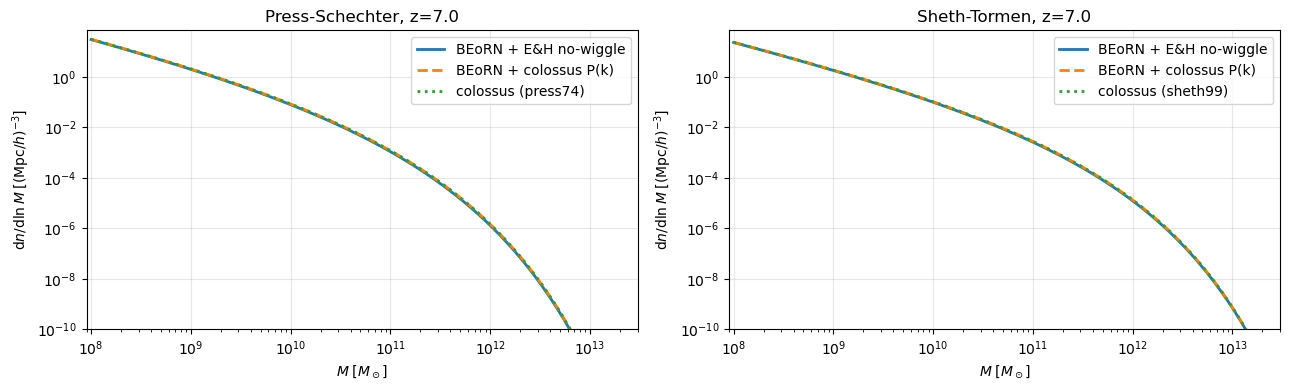

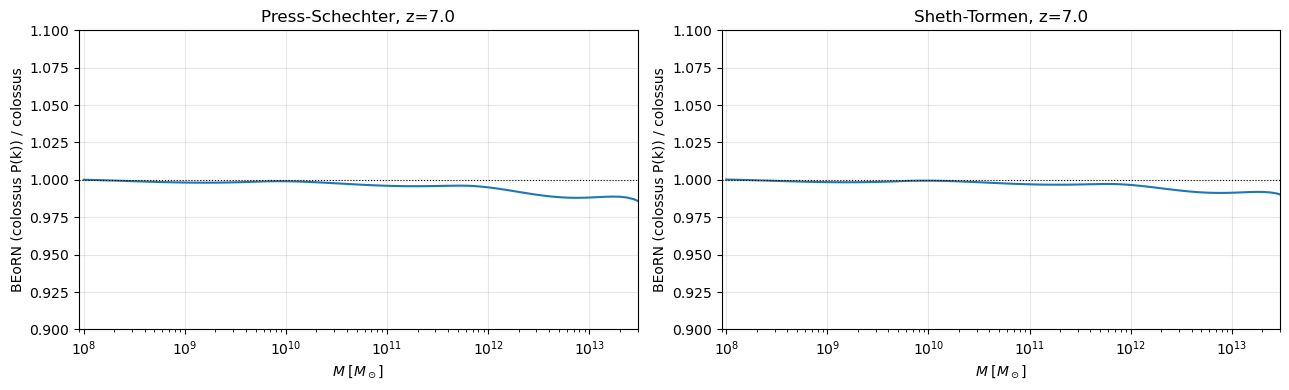

In [12]:
try:
    from colossus.cosmology import cosmology as col_cosmo
    from colossus.lss import mass_function as col_mf
    _COLOSSUS_AVAILABLE = True
except ImportError:
    _COLOSSUS_AVAILABLE = False
    print('colossus not installed — skipping comparison.')
    print('Install: pip install colossus')

if _COLOSSUS_AVAILABLE:
    from beorn.lpt import TabulatedPowerSpectrum

    # Set up colossus cosmology to match BEoRN param
    h = param.cosmology.h0
    cosmo_col = col_cosmo.setCosmology('planck18')
    cosmo_col = col_cosmo.setCosmology('custom', {
        'flat': True,
        'H0':   100 * h,
        'Om0':  param.cosmology.Om,
        'Ob0':  param.cosmology.Ob,
        'sigma8': param.cosmology.sigma_8,
        'ns':   param.cosmology.ns,
    })

    M_arr = M   # use the mass array from the setup cell

    # Build a dense k grid and evaluate the colossus power spectrum
    k_tab = np.logspace(-4, 2, 800)
    Pk_tab = np.array([cosmo_col.matterPowerSpectrum(ki, z=0) for ki in k_tab])

    # Wrap it in TabulatedPowerSpectrum — renormalize=True rescales so that
    # sigma_8 computed from this table exactly matches param.cosmology.sigma_8
    ps_col = TabulatedPowerSpectrum(param, k_tab, Pk_tab, renormalize=True)

    # Build HMF with the colossus P(k) — uses BEoRN growth factor for z evolution
    hmf_col = HaloMassFunction(param, ps_method='tabulated', k=k_tab, Pk=Pk_tab)

    models_cmp = [
        ('press_schechter', 'press74', 'Press-Schechter'),
        ('sheth_tormen',    'sheth99', 'Sheth-Tormen'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (beorn_model, col_model, label) in zip(axes, models_cmp):
        hmf_beorn_eh  = HaloMassFunction(param, model=beorn_model)         # E&H no-wiggle
        hmf_beorn_col = HaloMassFunction(param, model=beorn_model,
                                         ps_method='tabulated',
                                         k=k_tab, Pk=Pk_tab)               # colossus P(k)

        n_eh  = hmf_beorn_eh.dndlnm(M_arr, z=z)
        n_tab = hmf_beorn_col.dndlnm(M_arr, z=z)
        n_col = col_mf.massFunction(M_arr * h, z=z, mdef='fof',
                                    model=col_model, q_in='M', q_out='dndlnM')

        ax.loglog(M_arr, n_eh,  lw=2,          label='BEoRN + E&H no-wiggle')
        ax.loglog(M_arr, n_tab, lw=2, ls='--',  label='BEoRN + colossus P(k)')
        ax.loglog(M_arr, n_col, lw=2, ls=':',   label=f'colossus ({col_model})')
        ax.set_xlabel(r'$M\;[M_\odot]$')
        ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
        ax.set_title(f'{label}, z={z}')
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.set_ylim(1e-10, 70)
        ax.set_xlim(9e7, 3e13)
    plt.tight_layout(); plt.show()

    # Ratio plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (beorn_model, col_model, label) in zip(axes, models_cmp):
        hmf_beorn_col = HaloMassFunction(param, model=beorn_model,
                                         ps_method='tabulated',
                                         k=k_tab, Pk=Pk_tab)
        n_tab = hmf_beorn_col.dndlnm(M_arr, z=z)
        n_col = col_mf.massFunction(M_arr * h, z=z, mdef='fof',
                                    model=col_model, q_in='M', q_out='dndlnM')
        mask = n_col > 0
        ax.semilogx(M_arr[mask], n_tab[mask] / n_col[mask])
        ax.axhline(1, color='k', lw=0.8, ls=':')
        ax.set_xlabel(r'$M\;[M_\odot]$')
        ax.set_ylabel('BEoRN (colossus P(k)) / colossus')
        ax.set_title(f'{label}, z={z}')
        ax.set_ylim(0.9, 1.1); ax.grid(True, alpha=0.3)
        ax.set_xlim(9e7, 3e13)
    plt.tight_layout(); plt.show()
else:
    print('colossus not available — install with: pip install colossus')

## 11  JAX backend & HMF gradients

With `backend='jax'`, `f(\nu)` and `dn/d\ln M` are computed with JAX
operations on arrays converted from the pre-computed numpy sigma^2 grid.
This makes the result differentiable w.r.t.:

- `delta_c` — the linear collapse threshold
- `p`, `q`  — model shape parameters
- `A`       — normalisation

These are the HMF parameters inferred in Bayesian analyses.  The gradient
of the *cumulative number density* $n(>M_{\min})$ is particularly useful.

In [13]:
import jax
import jax.numpy as jnp

# Enable float64 in JAX (default is float32 which loses precision at high masses)
jax.config.update('jax_enable_x64', True)

# sigma^2 precomputation happens in numpy; only f(nu) runs in JAX
hmf_jax = HaloMassFunction(param, backend='jax')

# Verify JAX and numpy give the same result (mask near-zero tails)
n_jax = hmf_jax.dndlnm(M, z)
n_num = HaloMassFunction(param, backend='numpy').dndlnm(M, z)
valid = n_num > 1e-30
ratio = jnp.abs(n_jax[valid] / jnp.asarray(n_num)[valid] - 1)
print(f'JAX vs numpy  max|ratio-1| = {float(jnp.max(ratio)):.2e}')  # ~0 with x64 enabled

JAX vs numpy  max|ratio-1| = 2.22e-16


In [14]:
# n(>Mmin) = sum_M  dn/dlnM * dlnM
def n_total_jax(delta_c):
    return hmf_jax.dndlnm(M, z, delta_c=delta_c).sum() * dlnM

def n_total_p(p):
    return hmf_jax.dndlnm(M, z, p=p).sum() * dlnM

def n_total_q(q):
    return hmf_jax.dndlnm(M, z, q=q).sum() * dlnM

dc_ref, p_ref, q_ref = 1.686, 0.3, 0.707

dn_dc = jax.grad(n_total_jax)(dc_ref)
dn_dp = jax.grad(n_total_p)(p_ref)
dn_dq = jax.grad(n_total_q)(q_ref)

print(f'dn(>Mmin)/d(delta_c) = {float(dn_dc):.4e}  [(Mpc/h)^-3]')
print(f'dn(>Mmin)/d(p)       = {float(dn_dp):.4e}  [(Mpc/h)^-3]')
print(f'dn(>Mmin)/d(q)       = {float(dn_dq):.4e}  [(Mpc/h)^-3]')

# Finite-difference check
eps_fd = 1e-4
dn_dc_fd = (n_total_jax(dc_ref + eps_fd) - n_total_jax(dc_ref - eps_fd)) / (2 * eps_fd)
print(f'\nFinite-diff dn/d(delta_c) = {float(dn_dc_fd):.4e}')
print(f'Relative error vs JAX grad = {abs(float(dn_dc - dn_dc_fd)/float(dn_dc_fd)):.2e}')

dn(>Mmin)/d(delta_c) = -2.4675e+01  [(Mpc/h)^-3]
dn(>Mmin)/d(p)       = -9.1287e+00  [(Mpc/h)^-3]
dn(>Mmin)/d(q)       = -2.9421e+01  [(Mpc/h)^-3]

Finite-diff dn/d(delta_c) = -2.4675e+01
Relative error vs JAX grad = 3.89e-09


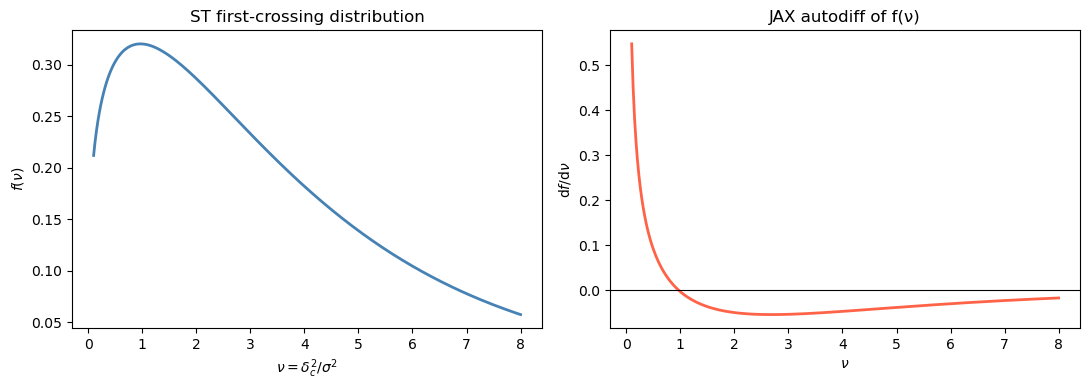

In [15]:
# df/dnu — derivative of the first-crossing distribution
nu_arr = jnp.linspace(0.1, 8.0, 300)

# ST f(nu) and its derivative
f_arr   = hmf_jax.f_nu(nu_arr)
df_dnu  = jax.vmap(jax.grad(lambda nu: hmf_jax.f_nu(jnp.array([nu]))[0]))(nu_arr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(nu_arr, f_arr,  lw=2, color='steelblue', label=r'$f(\nu)$')
ax.set_xlabel(r'$\nu = \delta_c^2 / \sigma^2$')
ax.set_ylabel(r'$f(\nu)$')
ax.set_title('ST first-crossing distribution')

ax = axes[1]
ax.plot(nu_arr, df_dnu, lw=2, color='tomato',    label=r'$\mathrm{d}f/\mathrm{d}\nu$ (JAX)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$\mathrm{d}f/\mathrm{d}\nu$')
ax.set_title('JAX autodiff of f(ν)')

plt.tight_layout()
plt.show()

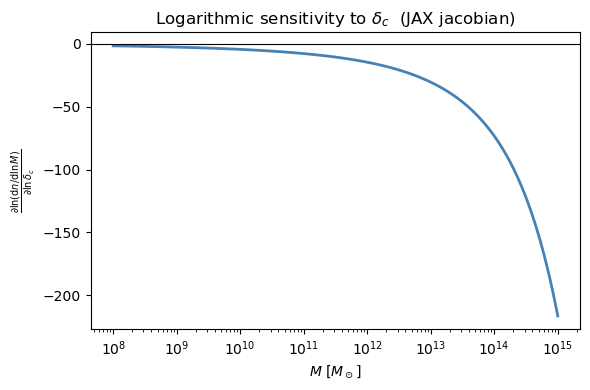

In [16]:
# Sensitivity of the HMF to delta_c at every mass bin
grad_per_bin = jax.jacobian(lambda dc: hmf_jax.dndlnm(M, z, delta_c=dc))(dc_ref)
# grad_per_bin[i] = d(dndlnM[i]) / d(delta_c)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(M, np.asarray(grad_per_bin) * dc_ref / np.array(n_num),
            lw=2, color='steelblue')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$M\ [M_\odot]$')
ax.set_ylabel(r'$\frac{\partial \ln(\mathrm{d}n/\mathrm{d}\ln M)}{\partial \ln\delta_c}$')
ax.set_title(r'Logarithmic sensitivity to $\delta_c$  (JAX jacobian)')
plt.tight_layout()
plt.show()

## 12  PyTorch backend & autograd

The same differentiability via PyTorch's `requires_grad` mechanism.
JAX and torch should give identical gradients.

In [17]:
try:
    import torch
    _TORCH_AVAILABLE = True
except ImportError:
    _TORCH_AVAILABLE = False
    print('torch not installed — skipping PyTorch backend comparison.')
    print('Install: pip install torch')

if _TORCH_AVAILABLE:
    hmf_torch = HaloMassFunction(param, backend='torch')

    # Gradient of n(>Mmin) w.r.t. delta_c
    dc_t = torch.tensor(dc_ref, dtype=torch.float64, requires_grad=True)
    n_t  = hmf_torch.dndlnm(M, z, delta_c=dc_t).sum() * dlnM
    n_t.backward()
    dn_dc_torch = dc_t.grad.item()
    print(f'dn(>Mmin)/d(delta_c) [torch] = {dn_dc_torch:.4e}')
    print(f'dn(>Mmin)/d(delta_c) [JAX]   = {float(dn_dc):.4e}')
    print(f'Relative diff JAX vs torch    = {abs(dn_dc_torch - float(dn_dc)) / abs(dn_dc_torch):.2e}')

dn(>Mmin)/d(delta_c) [torch] = -2.4675e+01
dn(>Mmin)/d(delta_c) [JAX]   = -2.4675e+01
Relative diff JAX vs torch    = 1.44e-16


In [18]:
if _TORCH_AVAILABLE:
    # Gradient w.r.t. multiple parameters simultaneously (torch jacobian)
    def hmf_output(dc, p, q):
        return hmf_torch.dndlnm(M, z, delta_c=dc, p=float(p), q=float(q))

    dc_t = torch.tensor(dc_ref, dtype=torch.float64, requires_grad=True)
    p_t  = torch.tensor(p_ref,  dtype=torch.float64, requires_grad=True)
    q_t  = torch.tensor(q_ref,  dtype=torch.float64, requires_grad=True)

    # Gradient of total count w.r.t. each parameter
    n_out = hmf_torch.dndlnm(M, z, delta_c=dc_t, p=p_t, q=q_t).sum() * dlnM
    n_out.backward()

    print(f'dn/d(delta_c) = {dc_t.grad.item():.4e}')
    print(f'dn/d(p)       = {p_t.grad.item():.4e}')
    print(f'dn/d(q)       = {q_t.grad.item():.4e}')

dn/d(delta_c) = -2.4675e+01
dn/d(p)       = -9.1287e+00
dn/d(q)       = -2.9421e+01


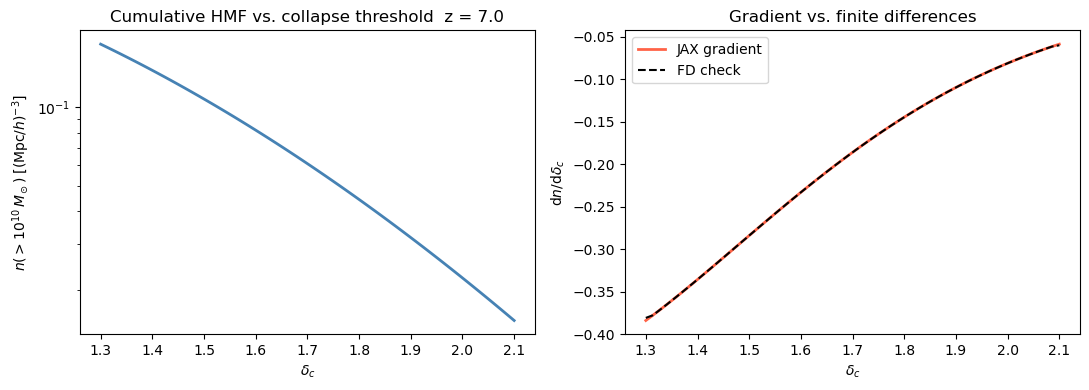

In [19]:
# Sweep: how does n(>1e10 Msun) change as delta_c varies?
dc_vals = np.linspace(1.3, 2.1, 60)

if _TORCH_AVAILABLE:
    n_vals = np.array([
        float(hmf_torch.dndlnm(M[M >= 1e10], z, delta_c=float(dc)).sum() * dlnM)
        for dc in dc_vals
    ])
else:
    # Fall back to numpy HMF for the sweep when torch is unavailable
    _hmf_np = HaloMassFunction(param, backend='numpy')
    n_vals = np.array([
        float(_hmf_np.dndlnm(M[M >= 1e10], z, delta_c=float(dc)).sum() * dlnM)
        for dc in dc_vals
    ])

# JAX gradient at each delta_c
grad_vals = np.array([
    float(jax.grad(lambda dc: hmf_jax.dndlnm(M[M >= 1e10], z, delta_c=dc).sum() * dlnM)(float(dc)))
    for dc in dc_vals
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.semilogy(dc_vals, n_vals, lw=2, color='steelblue')
ax.set_xlabel(r'$\delta_c$')
ax.set_ylabel(r'$n(>10^{10}\,M_\odot)\;[(\mathrm{Mpc}/h)^{-3}]$')
ax.set_title(f'Cumulative HMF vs. collapse threshold  z = {z}')

ax = axes[1]
ax.plot(dc_vals, grad_vals, lw=2, color='tomato', label='JAX gradient')
# Finite-difference check
fd_grad = np.gradient(n_vals, dc_vals)
ax.plot(dc_vals, fd_grad, lw=1.5, ls='--', color='k', label='FD check')
ax.set_xlabel(r'$\delta_c$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\delta_c$')
ax.set_title('Gradient vs. finite differences')
ax.legend()

plt.tight_layout()
plt.show()

## Summary

| Feature | Status |
|---|---|
| E&H no-wiggle P(k), σ₈-normalised | ✅ |
| E&H wiggle P(k) with BAO | ✅ |
| σ₈ normalisation check | ✅ |
| CAMB comparison (shape + growth factor) | ✅ |
| DISCO-EB Boltzmann comparison | ✅ (optional extra) |
| ∂P/∂A_s, ∂P/∂n_s via JAX (T² frozen) | ✅ |
| ∂P/∂Ω_m, ∂P/∂Ω_b via DISCO-EB (full) | 🔲 planned |
| HMF: Sheth-Tormen, Press-Schechter, Ellipsoidal | ✅ |
| Window functions: TopHat, SharpK, SmoothK | ✅ |
| Validation against colossus | ✅ (optional extra) |
| JAX backend & dn/dlnM gradients | ✅ |
| PyTorch backend & dn/dlnM autograd | ✅ |